### Dataset Exploration Notebook

In [1]:
import polars as pl
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

In [2]:
# df_index_hierarchy = pl.read_csv(
#     "../../datasets/google-landmark/index_label_to_hierarchical.csv"
# )
df_train_hierarchy = pl.read_csv("../../datasets/google-landmark/train_label_to_hierarchical.csv")
# df_index_landmark = pl.read_csv(
#     "../../datasets/google-landmark/index_image_to_landmark.csv"
# )
df_train_landmark = pl.read_csv("../../datasets/google-landmark/train_image_to_landmark.csv")
# df_index_latlon = pl.read_csv("../../datasets/google-landmark/index_w_latlon.csv")
df_train_latlon = pl.read_csv("../../datasets/google-landmark/train_w_latlon.csv")

In [3]:
df_train_latlon = df_train_latlon.join(
    df_train_hierarchy, left_on="input_url", right_on="category"
).with_columns(pl.col("landmark_id_right").alias("landmark_id")).drop(
    "landmark_id_right"
)

In [12]:
import os
imgs = [img.strip(".jpg") for img in os.listdir("../../datasets/google-landmark/train-img")]
df_img_file = pl.DataFrame(imgs, schema=["id"])

# pl.read_csv("../../datasets/google-landmark/index_ref.csv").join(df_img_file, on="id").write_csv("../../datasets/google-landmark/index_ref.csv")
# pl.read_csv("../../datasets/google-landmark/index_test.csv").join(df_img_file, on="id").write_csv("../../datasets/google-landmark/index_test.csv")
pl.read_csv("../../datasets/google-landmark/train_processed.csv").join(df_img_file, on="id").write_csv("../../datasets/google-landmark/train_processed.csv")

### Wikimedia Commons Coordinate Scraper
This scraper handles moved category pages and parses GeoHack coordinates into decimal latitude/longitude.

In [86]:
import asyncio
from collections import deque
from dataclasses import dataclass
from typing import Optional
from urllib.parse import parse_qs, unquote, urljoin, urlparse

import httpx
import polars as pl
from bs4 import BeautifulSoup
from tqdm import tqdm

GEO_DOMAINS = ("geohack.toolforge.org", "tools.wmflabs.org")
MOVED_KEYWORDS = (
    "moved",
    "renamed",
    "redirect",
    "now at",
    "see",
    "has moved",
    "replaced by",
    "use category",
)
DEFAULT_HEADERS = {
    "User-Agent": (
        "Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 "
        "(KHTML, like Gecko) Chrome/122.0.0.0 Safari/537.36"
    ),
    "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,*/*;q=0.8",
    "Accept-Language": "en-US,en;q=0.9",
    "Referer": "https://commons.wikimedia.org/",
}
RETRY_STATUS_CODES = {403, 429, 500, 502, 503, 504}


@dataclass
class CommonsCoordinateResult:
    input_url: str
    resolved_url: str
    geohack_url: str
    latitude: float
    longitude: float


def _to_decimal(parts: list[str], hemisphere: str) -> float:
    vals = [float(p.replace(",", ".")) for p in parts if p]
    if not vals:
        raise ValueError("No DMS parts found")

    deg = vals[0]
    minutes = vals[1] if len(vals) > 1 else 0.0
    seconds = vals[2] if len(vals) > 2 else 0.0
    decimal = abs(deg) + minutes / 60.0 + seconds / 3600.0

    if hemisphere in ("S", "W"):
        decimal *= -1
    if deg < 0:
        decimal *= -1

    return decimal


def parse_geohack_params(params_value: str) -> tuple[float, float]:
    tokens = [t for t in unquote(params_value).split("_") if t]

    lat_idx = next((i for i, t in enumerate(tokens) if t in ("N", "S")), None)
    if lat_idx is None:
        raise ValueError(f"Cannot find latitude hemisphere in params={params_value}")

    lon_idx = next(
        (
            i
            for i, t in enumerate(tokens[lat_idx + 1 :], start=lat_idx + 1)
            if t in ("E", "W")
        ),
        None,
    )
    if lon_idx is None:
        raise ValueError(f"Cannot find longitude hemisphere in params={params_value}")

    lat_parts = tokens[:lat_idx]
    lon_parts = tokens[lat_idx + 1 : lon_idx]

    lat = _to_decimal(lat_parts, tokens[lat_idx])
    lon = _to_decimal(lon_parts, tokens[lon_idx])
    return lat, lon


def parse_geohack_url(geohack_url: str) -> tuple[float, float]:
    query = parse_qs(urlparse(geohack_url).query)
    params_values = query.get("params")
    if not params_values:
        raise ValueError(f"No params query in geohack URL: {geohack_url}")
    return parse_geohack_params(params_values[0])


def _is_category_wiki_link(full_url: str) -> bool:
    p = urlparse(full_url)
    return (p.hostname or "").lower() == "commons.wikimedia.org" and p.path.startswith(
        "/wiki/Category:"
    )


def _find_geohack_link(soup: BeautifulSoup, base_url: str) -> Optional[str]:
    for a in soup.select("a[href]"):
        full = urljoin(base_url, a.get("href", ""))
        host = (urlparse(full).hostname or "").lower()
        if any(dom in host for dom in GEO_DOMAINS) and "params=" in full:
            return full
    return None


def _extract_candidate_links(soup: BeautifulSoup, base_url: str) -> list[str]:
    scored: list[tuple[int, str]] = []
    selectors = [
        ".redirectMsg a[href]",
        ".hatnote a[href]",
        ".mbox-text a[href]",
        ".mw-parser-output .notice a[href]",
        ".mw-parser-output .plainlinks a[href]",
    ]
    for sel in selectors:
        for a in soup.select(sel):
            full = urljoin(base_url, a.get("href", ""))
            if _is_category_wiki_link(full):
                scored.append((0, full))

    for block in soup.select(
        "#mw-content-text p, #mw-content-text li, #mw-content-text div, #mw-content-text td"
    ):
        if any(k in block.get_text(" ", strip=True).lower() for k in MOVED_KEYWORDS):
            for a in block.select("a[href]"):
                full = urljoin(base_url, a.get("href", ""))
                if _is_category_wiki_link(full):
                    scored.append((1, full))

    for a in soup.select('#mw-content-text a[href^="/wiki/Category:"]'):
        full = urljoin(base_url, a.get("href", ""))
        if _is_category_wiki_link(full):
            scored.append((2, full))

    canonical = soup.select_one('link[rel="canonical"]')
    if canonical and canonical.get("href"):
        full = canonical["href"]
        if _is_category_wiki_link(full):
            scored.append((1, full))

    scored.sort(key=lambda x: x[0])
    out: list[str] = []
    seen: set[str] = set()
    for _, u in scored:
        if u not in seen:
            seen.add(u)
            out.append(u)
    return out


async def _fetch_with_retries(
    client: httpx.AsyncClient, url: str, timeout: float, retries: int = 5
) -> httpx.Response:
    delay = 0.5
    for attempt in range(retries):
        try:
            resp = await client.get(url, timeout=timeout)
            if resp.status_code in RETRY_STATUS_CODES and attempt < retries - 1:
                await asyncio.sleep(delay * (2**attempt))
                continue
            resp.raise_for_status()
            return resp
        except (httpx.TimeoutException, httpx.NetworkError, httpx.RemoteProtocolError):
            if attempt >= retries - 1:
                raise
            await asyncio.sleep(delay * (2**attempt))
    raise RuntimeError("Retry loop exhausted")


async def scrape_commons_coordinates_async(
    client: httpx.AsyncClient,
    category_url: str,
    max_pages: int = 12,
    timeout: float = 20.0,
) -> CommonsCoordinateResult:
    queue: deque[str] = deque([category_url.replace("http://", "https://")])
    seen: set[str] = set()

    while queue and len(seen) < max_pages:
        url = queue.popleft()
        if url in seen:
            continue
        seen.add(url)

        resp = await _fetch_with_retries(client, url=url, timeout=timeout)
        resolved = str(resp.url)
        if resolved not in seen and len(seen) < max_pages:
            queue.appendleft(resolved)

        soup = BeautifulSoup(resp.text, "html.parser")
        geohack = _find_geohack_link(soup, resolved)
        if geohack:
            lat, lon = parse_geohack_url(geohack)
            return CommonsCoordinateResult(category_url, resolved, geohack, lat, lon)

        for next_url in _extract_candidate_links(soup, resolved):
            if next_url not in seen and next_url not in queue:
                queue.append(next_url)

    raise ValueError(
        f"No GeoHack coordinates found after scanning {len(seen)} page(s) for {category_url}"
    )


async def _scrape_one_with_semaphore(
    client: httpx.AsyncClient,
    sem: asyncio.Semaphore,
    url: str,
    max_pages: int,
    timeout: float,
) -> dict:
    async with sem:
        try:
            await asyncio.sleep(3)
            r = await scrape_commons_coordinates_async(
                client, url, max_pages=max_pages, timeout=timeout
            )
            return {
                "input_url": r.input_url,
                "resolved_url": r.resolved_url,
                "geohack_url": r.geohack_url,
                "latitude": r.latitude,
                "longitude": r.longitude,
                "error": None,
            }
        except Exception as e:
            return {
                "input_url": url,
                "resolved_url": None,
                "geohack_url": None,
                "latitude": None,
                "longitude": None,
                "error": str(e),
            }


async def scrape_many_coordinates(
    urls: list[str], concurrency: int = 20, max_pages: int = 12, timeout: float = 20.0
) -> list[dict]:
    sem = asyncio.Semaphore(concurrency)
    limits = httpx.Limits(
        max_connections=concurrency * 2, max_keepalive_connections=concurrency
    )

    async with httpx.AsyncClient(
        headers=DEFAULT_HEADERS, follow_redirects=True, limits=limits, http2=True
    ) as client:
        tasks = [
            asyncio.create_task(
                _scrape_one_with_semaphore(
                    client, sem, url, max_pages=max_pages, timeout=timeout
                )
            )
            for url in urls
        ]

        results: list[dict] = []
        success_count = 0
        error_count = 0
        with tqdm(total=len(tasks), desc="Scraping Wikimedia", unit="url") as pbar:
            for fut in asyncio.as_completed(tasks):
                item = await fut
                results.append(item)
                if item.get("error"):
                    error_count += 1
                else:
                    success_count += 1
                pbar.set_postfix(success=success_count, error=error_count)
                pbar.update(1)
        return results


# Example usage in notebook:
urls = df_index["category"].to_list()
# urls = [
#     "http://commons.wikimedia.org/wiki/Category:Happy_Valley_Racecourse",
#     "http://commons.wikimedia.org/wiki/Category:Luitpoldpark_in_Munich",
# ]

results = await scrape_many_coordinates(urls, concurrency=20)
df_results = pl.DataFrame(results)

Scraping Wikimedia:   0%|          | 59/67933 [00:14<4:33:41,  4.13url/s, error=0, success=59]


CancelledError: 

In [113]:
import csv

with open("../datasets/google-landmark/index_w_latlon.csv", "w") as f:
    writer = csv.DictWriter(
        f,
        fieldnames=[
            "landmark_id",
            "input_url",
            "resolved_url",
            "geohack_url",
            "latitude",
            "longitude",
            "error",
        ],
    )

    writer.writeheader()

    for idx, res in zip(df_index["landmark_id"].to_list(), results):
        writer.writerow({"landmark_id": idx, **res})

### Reverse Geocode

In [5]:
countries = [
    {"country": "Afghanistan", "continent": "Asia", "subregion": "South Asia"},
    {"country": "Albania", "continent": "Europe", "subregion": "Southern Europe"},
    {"country": "Algeria", "continent": "Africa", "subregion": "North Africa"},
    {"country": "Andorra", "continent": "Europe", "subregion": "Southern Europe"},
    {"country": "Argentina", "continent": "Americas", "subregion": "South America"},
    {"country": "Armenia", "continent": "Asia", "subregion": "Middle East"},
    {
        "country": "Australia",
        "continent": "Oceania",
        "subregion": "Australia & New Zealand",
    },
    {"country": "Austria", "continent": "Europe", "subregion": "Western Europe"},
    {"country": "Azerbaijan", "continent": "Asia", "subregion": "Middle East"},
    {"country": "Bahamas", "continent": "Americas", "subregion": "Caribbean"},
    {"country": "Bahrain", "continent": "Asia", "subregion": "Middle East"},
    {"country": "Bangladesh", "continent": "Asia", "subregion": "South Asia"},
    {"country": "Belarus", "continent": "Europe", "subregion": "Eastern Europe"},
    {"country": "Belgium", "continent": "Europe", "subregion": "Western Europe"},
    {"country": "Belize", "continent": "Americas", "subregion": "Central America"},
    {"country": "Benin", "continent": "Africa", "subregion": "West Africa"},
    {"country": "Bhutan", "continent": "Asia", "subregion": "South Asia"},
    {"country": "Bolivia", "continent": "Americas", "subregion": "South America"},
    {
        "country": "Bosnia and Herzegovina",
        "continent": "Europe",
        "subregion": "Southern Europe",
    },
    {"country": "Brazil", "continent": "Americas", "subregion": "South America"},
    {"country": "Bulgaria", "continent": "Europe", "subregion": "Eastern Europe"},
    {"country": "Burkina Faso", "continent": "Africa", "subregion": "West Africa"},
    {"country": "Cambodia", "continent": "Asia", "subregion": "Southeast Asia"},
    {"country": "Canada", "continent": "Americas", "subregion": "Northern America"},
    {"country": "Chile", "continent": "Americas", "subregion": "South America"},
    {"country": "China", "continent": "Asia", "subregion": "East Asia"},
    {"country": "Colombia", "continent": "Americas", "subregion": "South America"},
    {"country": "Costa Rica", "continent": "Americas", "subregion": "Central America"},
    {"country": "Croatia", "continent": "Europe", "subregion": "Southern Europe"},
    {"country": "Cuba", "continent": "Americas", "subregion": "Caribbean"},
    {"country": "Curacao", "continent": "Americas", "subregion": "Caribbean"},
    {"country": "Czechia", "continent": "Europe", "subregion": "Eastern Europe"},
    {"country": "Denmark", "continent": "Europe", "subregion": "Northern Europe"},
    {
        "country": "Dominican Republic",
        "continent": "Americas",
        "subregion": "Caribbean",
    },
    {"country": "Ecuador", "continent": "Americas", "subregion": "South America"},
    {"country": "Egypt", "continent": "Africa", "subregion": "North Africa"},
    {"country": "El Salvador", "continent": "Americas", "subregion": "Central America"},
    {"country": "Estonia", "continent": "Europe", "subregion": "Northern Europe"},
    {"country": "Ethiopia", "continent": "Africa", "subregion": "East Africa"},
    {
        "country": "Falkland Islands",
        "continent": "Americas",
        "subregion": "South America",
    },
    {"country": "Faroe Islands", "continent": "Europe", "subregion": "Northern Europe"},
    {"country": "Finland", "continent": "Europe", "subregion": "Northern Europe"},
    {"country": "France", "continent": "Europe", "subregion": "Western Europe"},
    {"country": "Georgia", "continent": "Asia", "subregion": "Middle East"},
    {"country": "Germany", "continent": "Europe", "subregion": "Western Europe"},
    {"country": "Ghana", "continent": "Africa", "subregion": "West Africa"},
    {"country": "Greece", "continent": "Europe", "subregion": "Southern Europe"},
    {"country": "Greenland", "continent": "Americas", "subregion": "Northern America"},
    {"country": "Grenada", "continent": "Americas", "subregion": "Caribbean"},
    {"country": "Guatemala", "continent": "Americas", "subregion": "Central America"},
    {"country": "Haiti", "continent": "Americas", "subregion": "Caribbean"},
    {"country": "Hungary", "continent": "Europe", "subregion": "Eastern Europe"},
    {"country": "Iceland", "continent": "Europe", "subregion": "Northern Europe"},
    {"country": "India", "continent": "Asia", "subregion": "South Asia"},
    {"country": "Indonesia", "continent": "Asia", "subregion": "Southeast Asia"},
    {"country": "Iran", "continent": "Asia", "subregion": "Middle East"},
    {"country": "Iraq", "continent": "Asia", "subregion": "Middle East"},
    {"country": "Ireland", "continent": "Europe", "subregion": "Northern Europe"},
    {"country": "Israel", "continent": "Asia", "subregion": "Middle East"},
    {"country": "Italy", "continent": "Europe", "subregion": "Southern Europe"},
    {"country": "Japan", "continent": "Asia", "subregion": "East Asia"},
    {"country": "Jersey", "continent": "Europe", "subregion": "Northern Europe"},
    {"country": "Jordan", "continent": "Asia", "subregion": "Middle East"},
    {"country": "Kazakhstan", "continent": "Asia", "subregion": "Central Asia"},
    {"country": "Kenya", "continent": "Africa", "subregion": "East Africa"},
    {"country": "Kuwait", "continent": "Asia", "subregion": "Middle East"},
    {"country": "Laos", "continent": "Asia", "subregion": "Southeast Asia"},
    {"country": "Latvia", "continent": "Europe", "subregion": "Northern Europe"},
    {"country": "Lebanon", "continent": "Asia", "subregion": "Middle East"},
    {"country": "Liberia", "continent": "Africa", "subregion": "West Africa"},
    {"country": "Libya", "continent": "Africa", "subregion": "North Africa"},
    {"country": "Liechtenstein", "continent": "Europe", "subregion": "Western Europe"},
    {"country": "Lithuania", "continent": "Europe", "subregion": "Northern Europe"},
    {"country": "Luxembourg", "continent": "Europe", "subregion": "Western Europe"},
    {"country": "Malawi", "continent": "Africa", "subregion": "East Africa"},
    {"country": "Malaysia", "continent": "Asia", "subregion": "Southeast Asia"},
    {"country": "Malta", "continent": "Europe", "subregion": "Southern Europe"},
    {"country": "Mauritius", "continent": "Africa", "subregion": "East Africa"},
    {"country": "Mexico", "continent": "Americas", "subregion": "Northern America"},
    {"country": "Moldova", "continent": "Europe", "subregion": "Eastern Europe"},
    {"country": "Monaco", "continent": "Europe", "subregion": "Western Europe"},
    {"country": "Mongolia", "continent": "Asia", "subregion": "East Asia"},
    {"country": "Montenegro", "continent": "Europe", "subregion": "Southern Europe"},
    {"country": "Morocco", "continent": "Africa", "subregion": "North Africa"},
    {"country": "Myanmar", "continent": "Asia", "subregion": "Southeast Asia"},
    {"country": "Nepal", "continent": "Asia", "subregion": "South Asia"},
    {"country": "Netherlands", "continent": "Europe", "subregion": "Western Europe"},
    {
        "country": "New Zealand",
        "continent": "Oceania",
        "subregion": "Australia & New Zealand",
    },
    {"country": "Nicaragua", "continent": "Americas", "subregion": "Central America"},
    {
        "country": "North Macedonia",
        "continent": "Europe",
        "subregion": "Southern Europe",
    },
    {"country": "Norway", "continent": "Europe", "subregion": "Northern Europe"},
    {"country": "Oman", "continent": "Asia", "subregion": "Middle East"},
    {"country": "Pakistan", "continent": "Asia", "subregion": "South Asia"},
    {
        "country": "Palestinian Territories",
        "continent": "Asia",
        "subregion": "Middle East",
    },
    {"country": "Peru", "continent": "Americas", "subregion": "South America"},
    {"country": "Philippines", "continent": "Asia", "subregion": "Southeast Asia"},
    {"country": "Poland", "continent": "Europe", "subregion": "Eastern Europe"},
    {"country": "Portugal", "continent": "Europe", "subregion": "Southern Europe"},
    {"country": "Qatar", "continent": "Asia", "subregion": "Middle East"},
    {"country": "Romania", "continent": "Europe", "subregion": "Eastern Europe"},
    {"country": "Russia", "continent": "Europe", "subregion": "Eastern Europe"},
    {"country": "Rwanda", "continent": "Africa", "subregion": "East Africa"},
    {"country": "Saudi Arabia", "continent": "Asia", "subregion": "Middle East"},
    {"country": "Senegal", "continent": "Africa", "subregion": "West Africa"},
    {"country": "Serbia", "continent": "Europe", "subregion": "Southern Europe"},
    {"country": "Singapore", "continent": "Asia", "subregion": "Southeast Asia"},
    {"country": "Slovakia", "continent": "Europe", "subregion": "Eastern Europe"},
    {"country": "Slovenia", "continent": "Europe", "subregion": "Southern Europe"},
    {"country": "Solomon Islands", "continent": "Oceania", "subregion": "Melanesia"},
    {"country": "South Africa", "continent": "Africa", "subregion": "Southern Africa"},
    {"country": "South Korea", "continent": "Asia", "subregion": "East Asia"},
    {"country": "Spain", "continent": "Europe", "subregion": "Southern Europe"},
    {"country": "Sri Lanka", "continent": "Asia", "subregion": "South Asia"},
    {"country": "Suriname", "continent": "Americas", "subregion": "South America"},
    {"country": "Sweden", "continent": "Europe", "subregion": "Northern Europe"},
    {"country": "Switzerland", "continent": "Europe", "subregion": "Western Europe"},
    {"country": "Syria", "continent": "Asia", "subregion": "Middle East"},
    {"country": "Taiwan", "continent": "Asia", "subregion": "East Asia"},
    {"country": "Thailand", "continent": "Asia", "subregion": "Southeast Asia"},
    {"country": "The Gambia", "continent": "Africa", "subregion": "West Africa"},
    {
        "country": "Trinidad and Tobago",
        "continent": "Americas",
        "subregion": "Caribbean",
    },
    {"country": "Tunisia", "continent": "Africa", "subregion": "North Africa"},
    {"country": "Turkey", "continent": "Asia", "subregion": "Middle East"},
    {"country": "Uganda", "continent": "Africa", "subregion": "East Africa"},
    {"country": "Ukraine", "continent": "Europe", "subregion": "Eastern Europe"},
    {
        "country": "United Arab Emirates",
        "continent": "Asia",
        "subregion": "Middle East",
    },
    {
        "country": "United Kingdom",
        "continent": "Europe",
        "subregion": "Northern Europe",
    },
    {
        "country": "United States",
        "continent": "Americas",
        "subregion": "Northern America",
    },
    {"country": "Uruguay", "continent": "Americas", "subregion": "South America"},
    {"country": "Uzbekistan", "continent": "Asia", "subregion": "Central Asia"},
    {"country": "Venezuela", "continent": "Americas", "subregion": "South America"},
    {"country": "Vietnam", "continent": "Asia", "subregion": "Southeast Asia"},
    {"country": "Zambia", "continent": "Africa", "subregion": "East Africa"},
    {"country": "Zimbabwe", "continent": "Africa", "subregion": "East Africa"},
]

df_map_countries = pl.DataFrame(countries)

In [6]:
import math
from typing import Iterable

import polars as pl
import reverse_geocoder as rg
from tqdm.auto import tqdm

import pandas as pd
from collections import defaultdict


url = "https://www.countrycode.org/"
df_cc = pd.read_html(url)[0]  # first table

# Keep only needed columns
df_cc = df_cc[["COUNTRY", "COUNTRY CODE", "ISO CODES"]].copy()

# 1) Phone country code -> list of country names (one code can map to many countries)
phone_code_to_countries = defaultdict(list)
for _, row in df_cc.iterrows():
    for code in str(row["COUNTRY CODE"]).split(","):
        code = code.strip()
        if row["COUNTRY"] not in phone_code_to_countries[code]:
            phone_code_to_countries[code].append(row["COUNTRY"])
phone_code_to_countries = dict(phone_code_to_countries)

# 2) ISO2 code -> country name (unique mapping)
df_cc = pl.DataFrame(
    [
        {
            "country_code": str(row["ISO CODES"]).split("/")[0].strip(),
            "country": row["COUNTRY"],
        }
        for _, row in df_cc.iterrows()
    ]
)
df_cc = df_cc.join(df_map_countries, on="country", how="left")


def _chunk_rows(
    rows: list[tuple[float, float]], chunk_size: int
) -> Iterable[list[tuple[float, float]]]:
    for i in range(0, len(rows), chunk_size):
        yield rows[i : i + chunk_size]


def reverse_geocode_df(
    df: pl.DataFrame,
    lat_col: str = "latitude",
    lon_col: str = "longitude",
    chunk_size: int = 250_000,
    rg_mode: int = 2,
) -> pl.DataFrame:
    # Keep null rows; only reverse geocode valid coordinates.
    valid = df.filter(
        pl.col(lat_col).is_not_null() & pl.col(lon_col).is_not_null()
    ).with_columns(
        pl.col(lat_col).cast(pl.Float64),
        pl.col(lon_col).cast(pl.Float64),
    )

    if valid.is_empty():
        return df.with_columns(
            pl.lit(None).cast(pl.String).alias("rg_name"),
            pl.lit(None).cast(pl.String).alias("rg_admin1"),
            pl.lit(None).cast(pl.String).alias("rg_admin2"),
            pl.lit(None).cast(pl.String).alias("rg_cc"),
            pl.lit(None).cast(pl.Float64).alias("rg_lat"),
            pl.lit(None).cast(pl.Float64).alias("rg_lon"),
        )

    # Huge speed-up for datasets with repeated coordinates.
    unique_coords = (
        valid.select([lat_col, lon_col])
        .unique(maintain_order=True)
        .with_row_index("coord_id")
    )

    coord_rows = unique_coords.select([lat_col, lon_col]).iter_rows()
    coord_rows = list(coord_rows)

    results: list[dict] = []
    total_chunks = math.ceil(len(coord_rows) / chunk_size)

    for batch in tqdm(
        _chunk_rows(coord_rows, chunk_size),
        total=total_chunks,
        desc="Reverse geocoding batches",
        unit="batch",
    ):
        # mode=2 uses multiprocessing in reverse_geocoder.
        batch_res = rg.search(batch, mode=rg_mode, verbose=False)
        results.extend(batch_res)

    rg_df = (
        pl.DataFrame(results)
        .with_row_index("coord_id")
        .rename(
            {
                "name": "rg_name",
                "admin1": "rg_admin1",
                "admin2": "rg_admin2",
                "cc": "country_code",
                "lat": "rg_lat",
                "lon": "rg_lon",
            }
        )
        .with_columns(
            pl.col("rg_lat").cast(pl.Float64),
            pl.col("rg_lon").cast(pl.Float64),
        )
        .join(df_cc, on="country_code")
    )

    lookup = unique_coords.join(rg_df, on="coord_id", how="left").drop("coord_id")

    return df.with_columns(
        pl.col(lat_col).cast(pl.Float64),
        pl.col(lon_col).cast(pl.Float64),
    ).join(
        lookup,
        on=[lat_col, lon_col],
        how="left",
    )


In [7]:
# Reverse geocode at scale (millions of rows)
# Tune chunk_size based on RAM/CPU. Start around 100k-300k.

# index_df = pl.read_csv("../../datasets/google-landmark/index_w_latlon.csv")
# df_index_latlon = reverse_geocode_df(df_index_latlon, chunk_size=250_000, rg_mode=2).drop(
#     ["rg_lat", "rg_lon"]
# ).join(df_index_landmark, on="landmark_id")
# df_index_latlon.filter(pl.col("error").is_null()).write_csv("../../datasets/google-landmark/index_processed.csv")

# index_df_rg.write_csv("../../datasets/google-landmark/index_w_latlon.csv")


# train_df = pl.read_csv("../../datasets/google-landmark/train_w_latlon.csv")
# train_df_rg = reverse_geocode_df(train_df, chunk_size=250_000, rg_mode=2).drop(
#     ["rg_lat", "rg_lon"]
# )
# train_df_rg.write_csv("../../datasets/google-landmark/train_w_latlon.csv")

df_train_latlon = reverse_geocode_df(df_train_latlon, chunk_size=250_000, rg_mode=2).drop(
    ["rg_lat", "rg_lon"]
).join(df_train_landmark, on="landmark_id")
df_train_latlon = df_train_latlon.filter(pl.col("error").is_null())
# df_train_latlon.write_csv("../../datasets/google-landmark/train_processed.csv")

Reverse geocoding batches:   0%|          | 0/1 [00:00<?, ?batch/s]

### Label Reduction

In [ ]:
import polars as pl


def _label_reduction_expr(source_col: str = "source_label") -> pl.Expr:
    clean = (
        pl.col(source_col)
        .cast(pl.Utf8)
        .str.to_lowercase()
        .str.replace_all(r"\([^)]*\)", " ")
        .str.replace_all(r"[^a-z0-9]+", " ")
        .str.replace_all(r"\s+", " ")
        .str.strip_chars()
        .str.replace_all(r"\bch teau\b", "chateau")
    )

    # Priority order matters: first match wins -> non-overlapping class assignment.
    rules: list[tuple[str, str]] = [
        (
            "park",
            r"\b(state|national|regional|provincial|county|city|urban|theme|water|nature)?\s*parks?\b|\bnational park system unit\b|\b(protected area|nature reserve|naturschutzgebiet|naturpark|national wildlife refuge|biosphere reserve|wilderness area|natura 2000 protected area|royal forest)\b",
        ),
        ("museum", r"\b(museum|gallery|exhibition hall|cultural center)s?\b"),
        ("church", r"\b(church|cathedral|basilica|chapel)s?\b"),
        ("mosque", r"\bmosques?\b"),
        ("temple", r"\btemples?\b"),
        ("monastery", r"\b(monastery|abbey|priory|convent|stift|cloister)s?\b"),
        ("shrine", r"\b(shrine|sanctuary|synagogue|wat|pagoda|hermitage)s?\b"),
        ("castle", r"\b(castle|chateau|rocca|kremlin|keep|hillfort|castrum)s?\b"),
        ("palace", r"\b(palace|palazzo)s?\b"),
        ("fort", r"\b(fort|fortress|citadel|fortification)s?\b"),
        ("bridge", r"\b\w*bridges?\b|\baqueduct\b"),
        ("tower", r"\b(tower|campanile|minaret|belfry)s?\b"),
        ("lighthouse", r"\blighthouses?\b"),
        (
            "monument",
            r"\b(monument|memorial|obelisk|heritage|mausoleum|triumphal arch|tomb|cenotaph|dolmen|megalith|column|well|fountain|gate|stepwell)s?\b",
        ),
        ("cemetery", r"\b(cemetery|graveyard|necropolis|war graves?)\b"),
        ("square", r"\b(square|plaza|piazza|place|marketplace)s?\b"),
        (
            "street",
            r"\b(street|road|avenue|boulevard|lane|highway|thoroughfare|promenade|traffic circle)s?\b",
        ),
        (
            "station",
            r"\b(railway|train|metro|subway|tram|junction) stations?\b|\bstations? (railway|train|metro|subway|tram)\b",
        ),
        (
            "railway line",
            r"\b(railway|railroad|tram|funicular|rail trail) lines?\b|\brailway line\b|\brailroad line\b",
        ),
        ("airport", r"\b(airport|airfield|aerodrome)s?\b"),
        (
            "stadium",
            r"\b(stadium|arena|sports venue|ballpark|racetrack|race track|horse racing venue|association football venue|bullring|cricket field)s?\b",
        ),
        (
            "theatre",
            r"\b(theatre|theater|opera|cinema|playhouse|performing arts center|amphitheatre|amphitheater)s?\b",
        ),
        ("library", r"\b(library|archives?)\b"),
        ("school", r"\b(school|college|university|campus|faculty|academy|institute)\b"),
        ("zoo", r"\b(zoos?|aquarium|aquaria)\b"),
        ("garden", r"\b(garden|botanical garden|arboretum|parkland|green space)s?\b"),
        (
            "mountain",
            r"\b(mountain|mount|volcano|peak|hill|ridge|summit|massif|sierra|inselberg|stratovolcano|mittlegebirge|mittelgebirge)s?\b",
        ),
        ("waterfall", r"\bwaterfalls?\b"),
        ("lake", r"\b(lake|reservoir|lagoon|pond|loch)s?\b"),
        ("river", r"\b(river|stream|creek|watercourse|estuary)s?\b"),
        ("canal", r"\b(canals?|waterway|ditch|gracht)\b"),
        ("beach", r"\b(beach|shore|coast|cove)s?\b"),
        ("island", r"\b(island|islet|archipelago)s?\b"),
        ("cave", r"\b(cave|grotto|cavern)s?\b"),
        ("dam", r"\bdams?\b"),
        (
            "archaeological site",
            r"\b(archaeological site|ruins?|excavation site|historic site|roman limes)\b",
        ),
        (
            "building",
            r"\b(building|skyscraper|house|residence|hall|courthouse|city hall|architectural structure|office|hotel|villa|estate|rathaus|mansion|hospital|embassy|factory|warehouse|prison|department store|shopping mall|shopping center|restaurant|farm|pavilion|convention center|windmill|watermill|mine)s?\b",
        ),
        (
            "settlement",
            r"\b(city|town|village|municipality|district|neighbourhood|neighborhood|settlement|hamlet|quarter|suburb|civil parish|parish|locality|freguesia|ortsteil|comuna)s?\b",
        ),
        (
            "landscape",
            r"\b(landform|valley|bay|canyon|cape|forest|peninsula|cliff|rock formation|fjord|glacier|gorge|wadi|desert|strait|headland|swamp|bog|dune|inlet|sea|natural landscape|geographical feature|geographic location|geographic region|natural region|vegetation zone)s?\b",
        ),
        ("port", r"\b(port|harbor|harbour|seaport|pier|marina)s?\b"),
    ]

    expr = pl.when(clean.is_null() | (clean == "")).then(pl.lit(None, dtype=pl.Utf8))
    for reduced, pattern in rules:
        expr = expr.when(clean.str.contains(pattern)).then(pl.lit(reduced))

    # Closed taxonomy for stable, non-overlapping labels.
    return expr.otherwise(pl.lit("other")).alias("reduced_label")


def reduce_landmark_labels(df: pl.DataFrame) -> pl.DataFrame:
    return df.with_columns(
        pl.coalesce([pl.col("supercategory"), pl.col("hierarchical_label")]).alias(
            "source_label"
        )
    ).with_columns(_label_reduction_expr("source_label"))


train_df = pl.read_csv("../datasets/google-landmark/train_w_latlon_labels.csv")
index_df = pl.read_csv("../datasets/google-landmark/index_w_latlon_labels.csv")

train_reduced = reduce_landmark_labels(train_df)
index_reduced = reduce_landmark_labels(index_df)

print(
    f"Train labels: {train_reduced.select(pl.col('source_label').n_unique()).item()} -> "
    f"{train_reduced.select(pl.col('reduced_label').n_unique()).item()}"
)
print(
    f"Index labels: {index_reduced.select(pl.col('source_label').n_unique()).item()} -> "
    f"{index_reduced.select(pl.col('reduced_label').n_unique()).item()}"
)

train_reduced.write_csv("../datasets/google-landmark/train_w_latlon_labels_reduced.csv")
index_reduced.write_csv("../datasets/google-landmark/index_w_latlon_labels_reduced.csv")

train_reduced.group_by("reduced_label").len().sort("len", descending=True).head(30)


Train labels: 4295 -> 42
Index labels: 4130 -> 41


reduced_label,len
str,u32
null,750356
"""church""",271738
"""other""",173032
"""park""",156603
"""building""",132669
…,…
"""tower""",18840
"""street""",17632
"""theatre""",14259


In [115]:
df_latlon = pl.read_csv("../datasets/google-landmark/index_w_latlon.csv")
df_label = pl.read_csv("../datasets/google-landmark/index_label_to_hierarchical.csv")
df_train = pl.read_csv("../datasets/google-landmark/index_image_to_landmark.csv")

In [127]:
df_train

id,landmark_id
str,i64
"""fdf40612109ad174""",32888
"""5a6cc67c893daea6""",552
"""87b88acb68cdc1f1""",13626
"""c4ac217ce087b251""",8699
"""05f269bf32be9d3e""",30838
…,…
"""03947beda4345d37""",16254
"""5c11122e655fdf4e""",86165
"""9fff2d3c31495fa5""",48911


In [129]:
df_train.join(
    df_latlon,
    on="landmark_id",
    how="left",
).join(df_label, on="landmark_id", how="left").filter(
    pl.col("latitude").is_not_null()
    & pl.col("longitude").is_not_null()
    & pl.col("error").is_null()
).with_columns(
    pl.coalesce("supercategory", "hierarchical_label").alias("hierarchical_label")
).drop(["input_url", "error"]).select(
    [
        "id",
        "landmark_id",
        pl.col("resolved_url").alias("wikimedia_url"),
        "geohack_url",
        "latitude",
        "longitude",
        "supercategory",
        "hierarchical_label",
        "natural_or_human_made",
    ]
).write_csv("../datasets/google-landmark/index_w_latlon_labels.csv")

In [ ]:
train_dict = pl.read_csv(
    "../datasets/google-landmark/train_w_latlon_labels.csv"
).to_dicts()
index_dict = pl.read_csv(
    "../datasets/google-landmark/index_w_latlon_labels.csv"
).to_dicts()

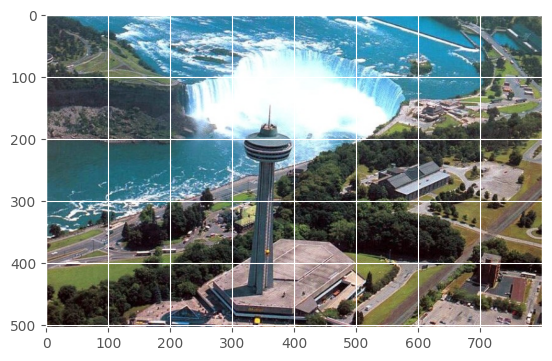

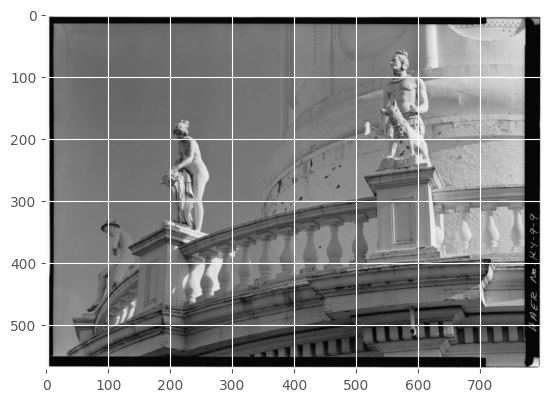

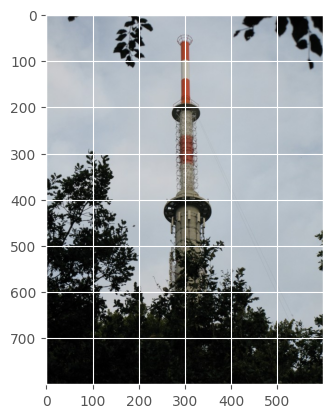

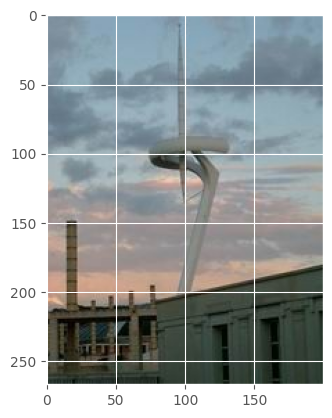

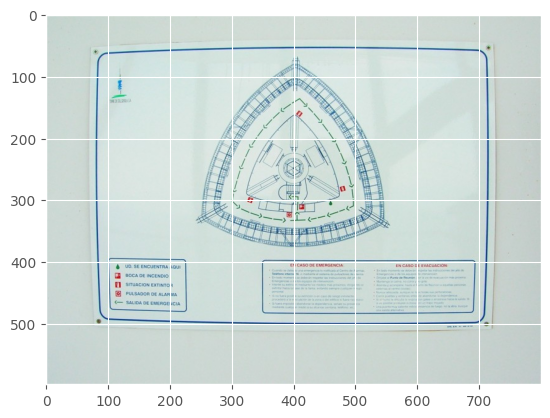

In [ ]:
from PIL import Image
import os
import matplotlib.pyplot as plt

for img in (
    pl.read_csv("../datasets/google-landmark/index_w_latlon_labels_reduced.csv")
    .filter(pl.col("reduced_label") == "tower")
    .head()["id"]
    .to_list()
):
    plt.imshow(
        Image.open(os.path.join("../datasets/google-landmark/index-img/", f"{img}.jpg"))
    )
    plt.show()

Region distribution (percent per split):
shape: (16, 4)
┌───────┬───────────────────────────┬────────┬───────────┐
│ split ┆ region                    ┆ len    ┆ pct       │
│ ---   ┆ ---                       ┆ ---    ┆ ---       │
│ str   ┆ str                       ┆ u32    ┆ f64       │
╞═══════╪═══════════════════════════╪════════╪═══════════╡
│ index ┆ Europe                    ┆ 306188 ┆ 58.948398 │
│ index ┆ North America             ┆ 107198 ┆ 20.638139 │
│ index ┆ Asia                      ┆ 38224  ┆ 7.35902   │
│ index ┆ Latin America & Caribbean ┆ 28488  ┆ 5.484611  │
│ index ┆ Africa                    ┆ 16328  ┆ 3.143524  │
│ …     ┆ …                         ┆ …      ┆ …         │
│ train ┆ Latin America & Caribbean ┆ 111516 ┆ 4.303052  │
│ train ┆ Africa                    ┆ 98016  ┆ 3.782129  │
│ train ┆ Other/Boundary            ┆ 73136  ┆ 2.822088  │
│ train ┆ Oceania                   ┆ 51978  ┆ 2.005668  │
│ train ┆ Antarctica                ┆ 1868   ┆ 0.07208   │


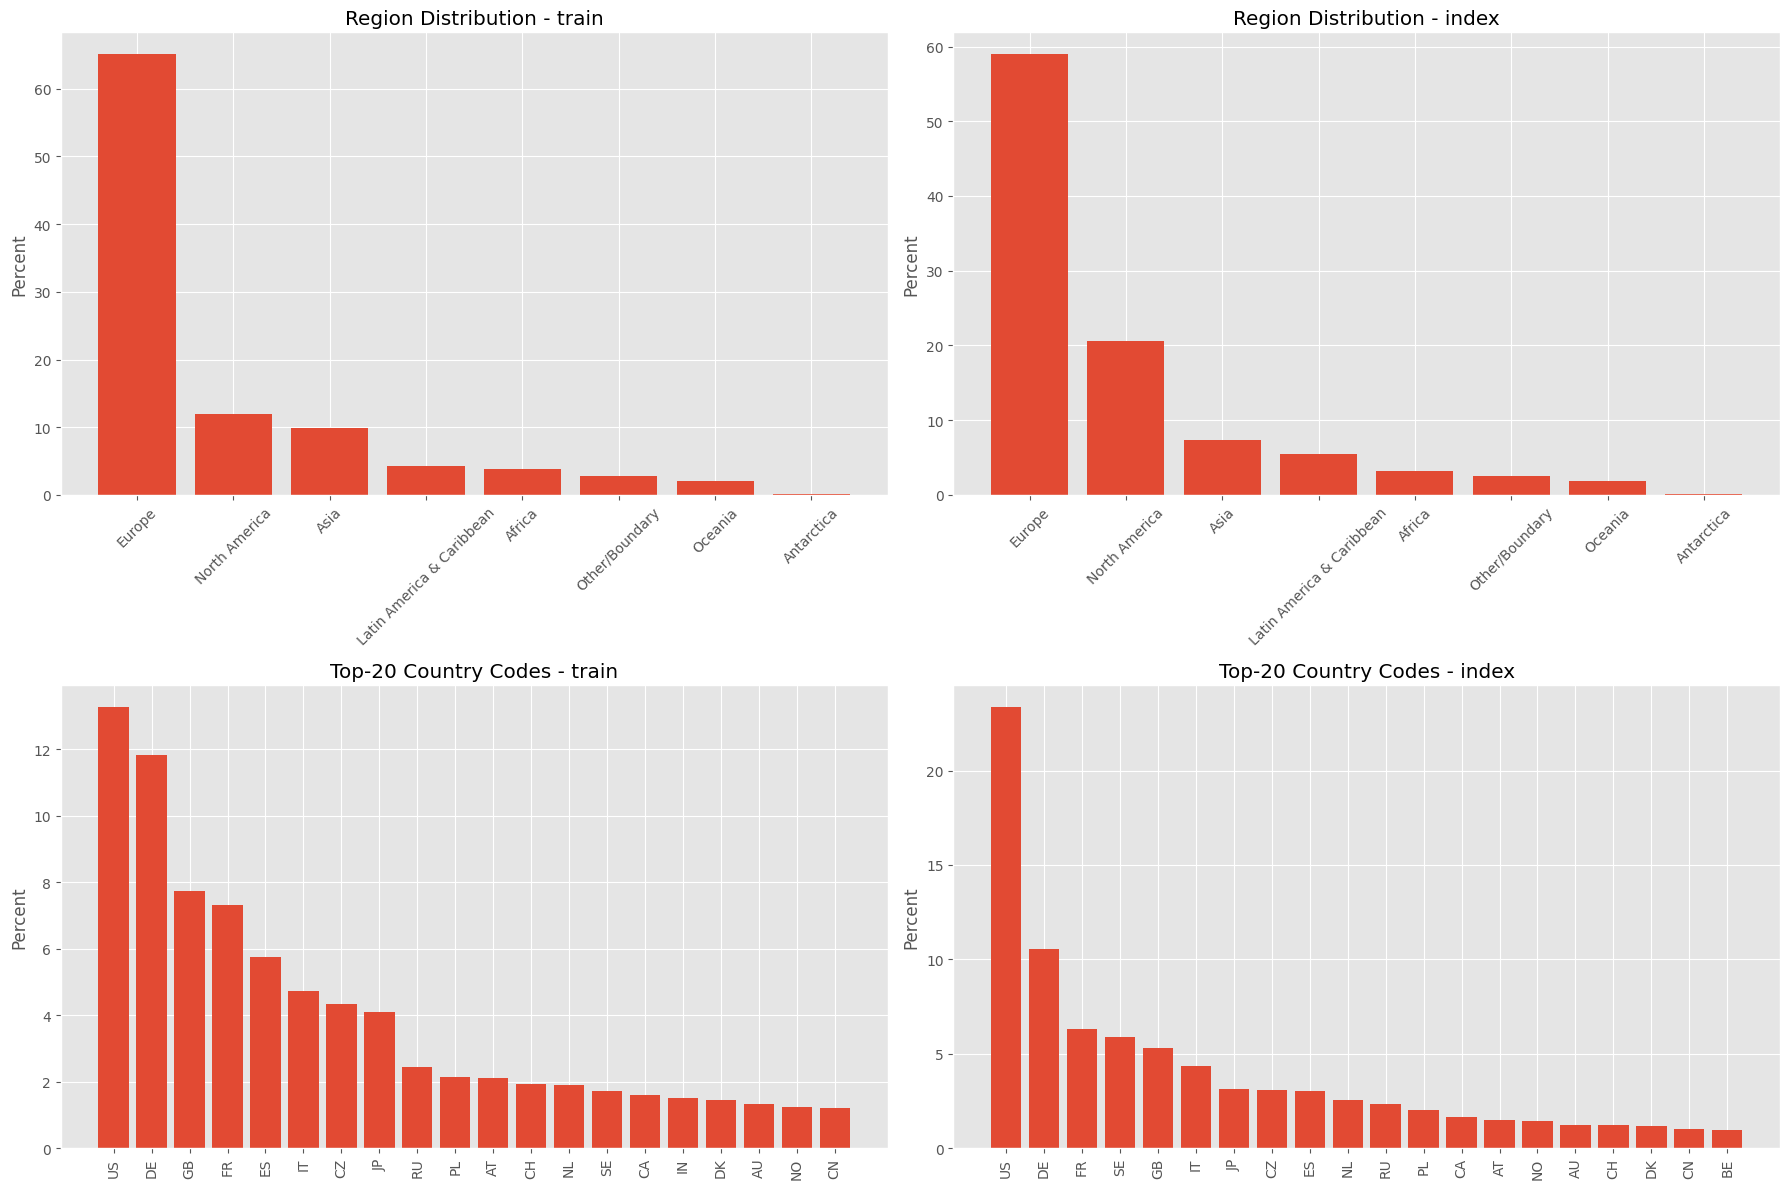

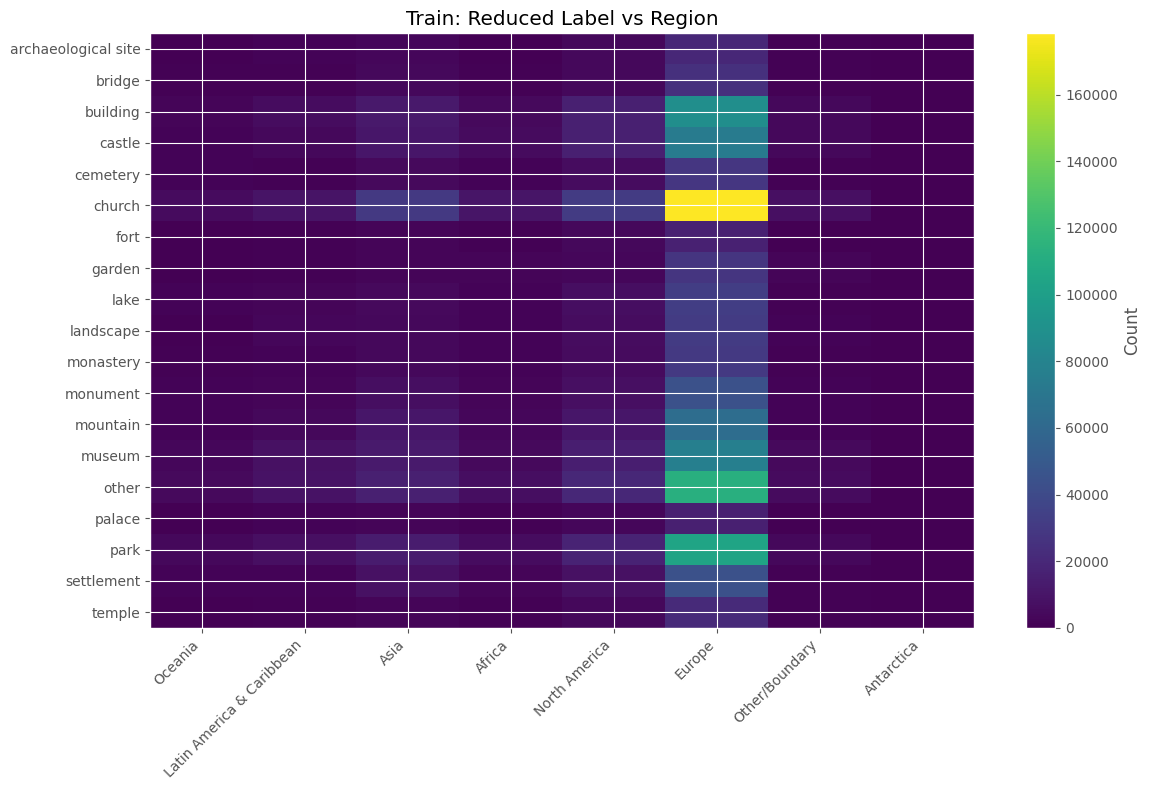

In [ ]:
import matplotlib.pyplot as plt
import polars as pl

# Load reduced datasets generated in previous cell
train = pl.read_csv(
    "../datasets/google-landmark/train_w_latlon_labels_reduced.csv"
).with_columns(pl.lit("train").alias("split"))
index = pl.read_csv(
    "../datasets/google-landmark/index_w_latlon_labels_reduced.csv"
).with_columns(pl.lit("index").alias("split"))

df = pl.concat([train, index], how="diagonal_relaxed")


def region_expr_from_latlon(
    lat_col: str = "latitude", lon_col: str = "longitude"
) -> pl.Expr:
    lat = pl.col(lat_col)
    lon = pl.col(lon_col)

    # Coarse geo-bounding regions (fast and dependency-free). Adjust bounds if needed.
    return (
        pl.when(lat.is_null() | lon.is_null())
        .then(pl.lit("Unknown"))
        .when((lat >= -35) & (lat <= 38) & (lon >= -20) & (lon <= 55))
        .then(pl.lit("Africa"))
        .when((lat >= 35) & (lat <= 72) & (lon >= -25) & (lon <= 60))
        .then(pl.lit("Europe"))
        .when((lat >= 5) & (lat <= 55) & (lon >= 60) & (lon <= 150))
        .then(pl.lit("Asia"))
        .when((lat >= -10) & (lat <= 35) & (lon >= -120) & (lon <= -30))
        .then(pl.lit("Latin America & Caribbean"))
        .when((lat >= 7) & (lat <= 83) & (lon >= -170) & (lon <= -50))
        .then(pl.lit("North America"))
        .when((lat >= -50) & (lat <= 0) & (lon >= 110) & (lon <= 180))
        .then(pl.lit("Oceania"))
        .when(lat < -60)
        .then(pl.lit("Antarctica"))
        .otherwise(pl.lit("Other/Boundary"))
    )


df = df.with_columns(region_expr_from_latlon().alias("region"))

# Optional country code cleaning
an = df.with_columns(pl.col("rg_cc").fill_null("UNK").alias("rg_cc"))

# ------------------------------
# 1) Balance summary tables
# ------------------------------
region_dist = (
    an.group_by(["split", "region"])
    .len()
    .with_columns(
        (pl.col("len") / pl.col("len").sum().over("split") * 100).alias("pct")
    )
    .sort(["split", "len"], descending=[False, True])
)

country_dist = (
    an.group_by(["split", "rg_cc"])
    .len()
    .with_columns(
        (pl.col("len") / pl.col("len").sum().over("split") * 100).alias("pct")
    )
    .sort(["split", "len"], descending=[False, True])
)

print("Region distribution (percent per split):")
print(region_dist)
print()
print("Top-20 countries per split:")
print(country_dist.group_by("split").head(20))

# Simple imbalance indicator: effective number of countries (higher means more balanced)
balance = (
    country_dist.with_columns((pl.col("pct") / 100.0).alias("p"))
    .group_by("split")
    .agg((1.0 / (pl.col("p") ** 2).sum()).alias("effective_num_countries"))
)
print()
print("Country balance indicator (effective number of countries):")
print(balance)

# ------------------------------
# 2) Plots
# ------------------------------
plt.style.use("ggplot")
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# (A) Region distribution by split
for i, split in enumerate(["train", "index"]):
    sub = region_dist.filter(pl.col("split") == split).sort("pct", descending=True)
    axes[0, i].bar(sub["region"].to_list(), sub["pct"].to_list())
    axes[0, i].set_title(f"Region Distribution - {split}")
    axes[0, i].set_ylabel("Percent")
    axes[0, i].tick_params(axis="x", rotation=45)

# (B) Top countries by split
for i, split in enumerate(["train", "index"]):
    sub = country_dist.filter(pl.col("split") == split).head(20)
    axes[1, i].bar(sub["rg_cc"].to_list(), sub["pct"].to_list())
    axes[1, i].set_title(f"Top-20 Country Codes - {split}")
    axes[1, i].set_ylabel("Percent")
    axes[1, i].tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

# ------------------------------
# 3) Label vs region heatmap (train split)
# ------------------------------
heat = (
    an.filter(pl.col("split") == "train")
    .group_by(["reduced_label", "region"])
    .len()
    .pivot(values="len", index="reduced_label", on="region")
    .fill_null(0)
)

# focus on top labels for readability
train_top_labels = (
    an.filter(pl.col("split") == "train")
    .group_by("reduced_label")
    .len()
    .sort("len", descending=True)
    .head(20)
    .select("reduced_label")
    .to_series()
    .to_list()
)

heat_small = heat.filter(pl.col("reduced_label").is_in(train_top_labels)).sort(
    "reduced_label"
)
region_cols = [c for c in heat_small.columns if c != "reduced_label"]
mat = heat_small.select(region_cols).to_numpy()

plt.figure(figsize=(12, 8))
plt.imshow(mat, aspect="auto")
plt.colorbar(label="Count")
plt.xticks(range(len(region_cols)), region_cols, rotation=45, ha="right")
plt.yticks(range(heat_small.height), heat_small["reduced_label"].to_list())
plt.title("Train: Reduced Label vs Region")
plt.tight_layout()
plt.show()

# Persist with region for downstream analysis
# an.write_csv("../datasets/google-landmark/all_w_latlon_labels_reduced_with_region.csv")


In [1]:
import polars as pl

mp16_train = pl.read_csv("../../datasets/mp16-reason/mp16-reason-train-annot-2.csv")
mp16_test = pl.read_csv("../../datasets/mp16-reason/mp16-reason-test-annot-2.csv")

In [22]:
import polars as pl


def region_expr_from_latlon(
    lat_col: str = "latitude", lon_col: str = "longitude"
) -> pl.Expr:
    lat = pl.col(lat_col)
    lon_raw = pl.col(lon_col)

    # Robustness: handle datasets using 0..360 longitude
    lon = pl.when(lon_raw > 180).then(lon_raw - 360).otherwise(lon_raw)

    return (
        pl.when(lat.is_null() | lon.is_null())
        .then(pl.lit("Unknown"))
        .when(lat < -60)
        .then(pl.lit("Antarctica"))
        # Americas first (expanded south bound)
        .when((lat >= -60) & (lat <= 35) & (lon >= -120) & (lon <= -25))
        .then(pl.lit("Latin America & Caribbean"))
        .when((lat >= 5) & (lat <= 85) & (lon >= -170) & (lon <= -50))
        .then(pl.lit("North America"))
        # Europe / Africa
        .when((lat >= 34) & (lat <= 82) & (lon >= -32) & (lon <= 40))
        .then(pl.lit("Europe"))
        .when((lat >= -38) & (lat <= 38) & (lon >= -25) & (lon <= 55))
        .then(pl.lit("Africa"))
        # Asia expanded (includes SE Asia + Middle East + Siberia/Far East)
        .when((lat >= -12) & (lat <= 82) & (lon >= 35) & (lon <= 180))
        .then(pl.lit("Asia"))
        # Oceania incl. near dateline islands
        .when(
            (lat >= -55)
            & (lat <= 30)
            & (((lon >= 110) & (lon <= 180)) | ((lon >= -180) & (lon <= -140)))
        )
        .then(pl.lit("Oceania"))
        # Final fallback: force continent instead of Other/Boundary
        .when(lon < -25)
        .then(
            pl.when(lat >= 5)
            .then(pl.lit("North America"))
            .otherwise(pl.lit("Latin America & Caribbean"))
        )
        .when((lon >= -25) & (lon < 35))
        .then(pl.when(lat >= 34).then(pl.lit("Europe")).otherwise(pl.lit("Africa")))
        .when((lon >= 35) & (lon <= 180))
        .then(pl.lit("Asia"))
        .otherwise(pl.lit("Oceania"))
    )


In [15]:
countries = [
    {"country": "Afghanistan", "continent": "Asia", "subregion": "South Asia"},
    {"country": "Albania", "continent": "Europe", "subregion": "Southern Europe"},
    {"country": "Algeria", "continent": "Africa", "subregion": "North Africa"},
    {"country": "Andorra", "continent": "Europe", "subregion": "Southern Europe"},
    {"country": "Argentina", "continent": "Americas", "subregion": "South America"},
    {"country": "Armenia", "continent": "Asia", "subregion": "Middle East"},
    {
        "country": "Australia",
        "continent": "Oceania",
        "subregion": "Australia & New Zealand",
    },
    {"country": "Austria", "continent": "Europe", "subregion": "Western Europe"},
    {"country": "Azerbaijan", "continent": "Asia", "subregion": "Middle East"},
    {"country": "Bahamas", "continent": "Americas", "subregion": "Caribbean"},
    {"country": "Bahrain", "continent": "Asia", "subregion": "Middle East"},
    {"country": "Bangladesh", "continent": "Asia", "subregion": "South Asia"},
    {"country": "Belarus", "continent": "Europe", "subregion": "Eastern Europe"},
    {"country": "Belgium", "continent": "Europe", "subregion": "Western Europe"},
    {"country": "Belize", "continent": "Americas", "subregion": "Central America"},
    {"country": "Benin", "continent": "Africa", "subregion": "West Africa"},
    {"country": "Bhutan", "continent": "Asia", "subregion": "South Asia"},
    {"country": "Bolivia", "continent": "Americas", "subregion": "South America"},
    {
        "country": "Bosnia and Herzegovina",
        "continent": "Europe",
        "subregion": "Southern Europe",
    },
    {"country": "Brazil", "continent": "Americas", "subregion": "South America"},
    {"country": "Bulgaria", "continent": "Europe", "subregion": "Eastern Europe"},
    {"country": "Burkina Faso", "continent": "Africa", "subregion": "West Africa"},
    {"country": "Cambodia", "continent": "Asia", "subregion": "Southeast Asia"},
    {"country": "Canada", "continent": "Americas", "subregion": "Northern America"},
    {"country": "Chile", "continent": "Americas", "subregion": "South America"},
    {"country": "China", "continent": "Asia", "subregion": "East Asia"},
    {"country": "Colombia", "continent": "Americas", "subregion": "South America"},
    {"country": "Costa Rica", "continent": "Americas", "subregion": "Central America"},
    {"country": "Croatia", "continent": "Europe", "subregion": "Southern Europe"},
    {"country": "Cuba", "continent": "Americas", "subregion": "Caribbean"},
    {"country": "Curacao", "continent": "Americas", "subregion": "Caribbean"},
    {"country": "Czechia", "continent": "Europe", "subregion": "Eastern Europe"},
    {"country": "Denmark", "continent": "Europe", "subregion": "Northern Europe"},
    {
        "country": "Dominican Republic",
        "continent": "Americas",
        "subregion": "Caribbean",
    },
    {"country": "Ecuador", "continent": "Americas", "subregion": "South America"},
    {"country": "Egypt", "continent": "Africa", "subregion": "North Africa"},
    {"country": "El Salvador", "continent": "Americas", "subregion": "Central America"},
    {"country": "Estonia", "continent": "Europe", "subregion": "Northern Europe"},
    {"country": "Ethiopia", "continent": "Africa", "subregion": "East Africa"},
    {
        "country": "Falkland Islands",
        "continent": "Americas",
        "subregion": "South America",
    },
    {"country": "Faroe Islands", "continent": "Europe", "subregion": "Northern Europe"},
    {"country": "Finland", "continent": "Europe", "subregion": "Northern Europe"},
    {"country": "France", "continent": "Europe", "subregion": "Western Europe"},
    {"country": "Georgia", "continent": "Asia", "subregion": "Middle East"},
    {"country": "Germany", "continent": "Europe", "subregion": "Western Europe"},
    {"country": "Ghana", "continent": "Africa", "subregion": "West Africa"},
    {"country": "Greece", "continent": "Europe", "subregion": "Southern Europe"},
    {"country": "Greenland", "continent": "Americas", "subregion": "Northern America"},
    {"country": "Grenada", "continent": "Americas", "subregion": "Caribbean"},
    {"country": "Guatemala", "continent": "Americas", "subregion": "Central America"},
    {"country": "Haiti", "continent": "Americas", "subregion": "Caribbean"},
    {"country": "Hungary", "continent": "Europe", "subregion": "Eastern Europe"},
    {"country": "Iceland", "continent": "Europe", "subregion": "Northern Europe"},
    {"country": "India", "continent": "Asia", "subregion": "South Asia"},
    {"country": "Indonesia", "continent": "Asia", "subregion": "Southeast Asia"},
    {"country": "Iran", "continent": "Asia", "subregion": "Middle East"},
    {"country": "Iraq", "continent": "Asia", "subregion": "Middle East"},
    {"country": "Ireland", "continent": "Europe", "subregion": "Northern Europe"},
    {"country": "Israel", "continent": "Asia", "subregion": "Middle East"},
    {"country": "Italy", "continent": "Europe", "subregion": "Southern Europe"},
    {"country": "Japan", "continent": "Asia", "subregion": "East Asia"},
    {"country": "Jersey", "continent": "Europe", "subregion": "Northern Europe"},
    {"country": "Jordan", "continent": "Asia", "subregion": "Middle East"},
    {"country": "Kazakhstan", "continent": "Asia", "subregion": "Central Asia"},
    {"country": "Kenya", "continent": "Africa", "subregion": "East Africa"},
    {"country": "Kuwait", "continent": "Asia", "subregion": "Middle East"},
    {"country": "Laos", "continent": "Asia", "subregion": "Southeast Asia"},
    {"country": "Latvia", "continent": "Europe", "subregion": "Northern Europe"},
    {"country": "Lebanon", "continent": "Asia", "subregion": "Middle East"},
    {"country": "Liberia", "continent": "Africa", "subregion": "West Africa"},
    {"country": "Libya", "continent": "Africa", "subregion": "North Africa"},
    {"country": "Liechtenstein", "continent": "Europe", "subregion": "Western Europe"},
    {"country": "Lithuania", "continent": "Europe", "subregion": "Northern Europe"},
    {"country": "Luxembourg", "continent": "Europe", "subregion": "Western Europe"},
    {"country": "Malawi", "continent": "Africa", "subregion": "East Africa"},
    {"country": "Malaysia", "continent": "Asia", "subregion": "Southeast Asia"},
    {"country": "Malta", "continent": "Europe", "subregion": "Southern Europe"},
    {"country": "Mauritius", "continent": "Africa", "subregion": "East Africa"},
    {"country": "Mexico", "continent": "Americas", "subregion": "Northern America"},
    {"country": "Moldova", "continent": "Europe", "subregion": "Eastern Europe"},
    {"country": "Monaco", "continent": "Europe", "subregion": "Western Europe"},
    {"country": "Mongolia", "continent": "Asia", "subregion": "East Asia"},
    {"country": "Montenegro", "continent": "Europe", "subregion": "Southern Europe"},
    {"country": "Morocco", "continent": "Africa", "subregion": "North Africa"},
    {"country": "Myanmar", "continent": "Asia", "subregion": "Southeast Asia"},
    {"country": "Nepal", "continent": "Asia", "subregion": "South Asia"},
    {"country": "Netherlands", "continent": "Europe", "subregion": "Western Europe"},
    {
        "country": "New Zealand",
        "continent": "Oceania",
        "subregion": "Australia & New Zealand",
    },
    {"country": "Nicaragua", "continent": "Americas", "subregion": "Central America"},
    {
        "country": "North Macedonia",
        "continent": "Europe",
        "subregion": "Southern Europe",
    },
    {"country": "Norway", "continent": "Europe", "subregion": "Northern Europe"},
    {"country": "Oman", "continent": "Asia", "subregion": "Middle East"},
    {"country": "Pakistan", "continent": "Asia", "subregion": "South Asia"},
    {
        "country": "Palestinian Territories",
        "continent": "Asia",
        "subregion": "Middle East",
    },
    {"country": "Peru", "continent": "Americas", "subregion": "South America"},
    {"country": "Philippines", "continent": "Asia", "subregion": "Southeast Asia"},
    {"country": "Poland", "continent": "Europe", "subregion": "Eastern Europe"},
    {"country": "Portugal", "continent": "Europe", "subregion": "Southern Europe"},
    {"country": "Qatar", "continent": "Asia", "subregion": "Middle East"},
    {"country": "Romania", "continent": "Europe", "subregion": "Eastern Europe"},
    {"country": "Russia", "continent": "Europe", "subregion": "Eastern Europe"},
    {"country": "Rwanda", "continent": "Africa", "subregion": "East Africa"},
    {"country": "Saudi Arabia", "continent": "Asia", "subregion": "Middle East"},
    {"country": "Senegal", "continent": "Africa", "subregion": "West Africa"},
    {"country": "Serbia", "continent": "Europe", "subregion": "Southern Europe"},
    {"country": "Singapore", "continent": "Asia", "subregion": "Southeast Asia"},
    {"country": "Slovakia", "continent": "Europe", "subregion": "Eastern Europe"},
    {"country": "Slovenia", "continent": "Europe", "subregion": "Southern Europe"},
    {"country": "Solomon Islands", "continent": "Oceania", "subregion": "Melanesia"},
    {"country": "South Africa", "continent": "Africa", "subregion": "Southern Africa"},
    {"country": "South Korea", "continent": "Asia", "subregion": "East Asia"},
    {"country": "Spain", "continent": "Europe", "subregion": "Southern Europe"},
    {"country": "Sri Lanka", "continent": "Asia", "subregion": "South Asia"},
    {"country": "Suriname", "continent": "Americas", "subregion": "South America"},
    {"country": "Sweden", "continent": "Europe", "subregion": "Northern Europe"},
    {"country": "Switzerland", "continent": "Europe", "subregion": "Western Europe"},
    {"country": "Syria", "continent": "Asia", "subregion": "Middle East"},
    {"country": "Taiwan", "continent": "Asia", "subregion": "East Asia"},
    {"country": "Thailand", "continent": "Asia", "subregion": "Southeast Asia"},
    {"country": "The Gambia", "continent": "Africa", "subregion": "West Africa"},
    {
        "country": "Trinidad and Tobago",
        "continent": "Americas",
        "subregion": "Caribbean",
    },
    {"country": "Tunisia", "continent": "Africa", "subregion": "North Africa"},
    {"country": "Turkey", "continent": "Asia", "subregion": "Middle East"},
    {"country": "Uganda", "continent": "Africa", "subregion": "East Africa"},
    {"country": "Ukraine", "continent": "Europe", "subregion": "Eastern Europe"},
    {
        "country": "United Arab Emirates",
        "continent": "Asia",
        "subregion": "Middle East",
    },
    {
        "country": "United Kingdom",
        "continent": "Europe",
        "subregion": "Northern Europe",
    },
    {
        "country": "United States",
        "continent": "Americas",
        "subregion": "Northern America",
    },
    {"country": "Uruguay", "continent": "Americas", "subregion": "South America"},
    {"country": "Uzbekistan", "continent": "Asia", "subregion": "Central Asia"},
    {"country": "Venezuela", "continent": "Americas", "subregion": "South America"},
    {"country": "Vietnam", "continent": "Asia", "subregion": "Southeast Asia"},
    {"country": "Zambia", "continent": "Africa", "subregion": "East Africa"},
    {"country": "Zimbabwe", "continent": "Africa", "subregion": "East Africa"},
]

df_map_countries = pl.DataFrame(countries)

In [ ]:
mp16_train = (
    mp16_train.with_columns(
        region_expr_from_latlon(lat_col="LAT", lon_col="LON").alias("continent")
    )
    .join(df_map_countries, on="country")
    .drop("continent_right")
)
mp16_test = (
    mp16_test.with_columns(
        region_expr_from_latlon(lat_col="LAT", lon_col="LON").alias("continent")
    )
    .join(df_map_countries, on="country")
    .drop("continent_right")
)

In [30]:
mp16_train.filter(
    (pl.col("label") != "unknown") & (pl.col("landmark_prob") >= 0.5)
).write_csv("../../datasets/mp16-reason/mp16-reason-train-annot-2-filtered.csv")
mp16_test.filter(
    (pl.col("label") != "unknown") & (pl.col("landmark_prob") >= 0.5)
).write_csv("../../datasets/mp16-reason/mp16-reason-test-annot-2-filtered.csv")

In [79]:
mp16_train.head()

idx,IMG_ID,AUTHOR,LAT,LON,S3_Label,S16_Label,S365_Label,Prob_indoor,Prob_natural,Prob_urban,neighbourhood,city,county,state,region,country,country_code,continent,reason,entities,landmark_prob,reason_right,label
i64,str,str,f64,f64,f64,f64,f64,f64,f64,f64,str,str,str,str,str,str,str,str,str,str,f64,str,str
0,"""11_53_8635985905.jpg""","""75394383@N00""",41.895733,12.484013,2.0,12.0,53.0,0.030819,0.003451,0.96573,"""Municipio Roma I""","""Rome""","""Roma Capitale""","""Lazio""",null,"""Italy""","""it""","""Europe""","""The architecture in the backgr…","""[{'text': 'white building', 't…",0.85,"""The primary subject is a large…","""monument"""
1,"""84_3a_3207322187.jpg""","""44124431847@N01""",48.872968,2.297462,2.0,11.0,12.0,8.8682e-7,0.004482,0.995517,"""Paris""","""Paris""",null,"""Ile-de-France""","""Metropolitan France""","""France""","""fr""","""Europe""","""The structure in the image is …","""[{'text': 'Arc de Triomphe', '…",0.9,"""The primary subject is the Arc…","""monument"""
2,"""8a_4b_6754899341.jpg""","""35065505@N03""",51.465985,-2.554528,2.0,10.0,291.0,0.00751,0.305245,0.687244,"""Whitehall""","""Bristol""","""City of Bristol""","""England""",null,"""United Kingdom""","""gb""","""Europe""","""The image shows a suspension b…","""[{'text': 'suspension bridge',…",0.9,"""The primary subject is a suspe…","""bridge"""
3,"""00_d7_6828292418.jpg""","""68968333@N06""",39.757327,-84.185539,0.0,5.0,329.0,0.985032,0.000144,0.014824,"""Oregon Historic District""","""Dayton""","""Montgomery County""","""Ohio""",null,"""United States""","""us""","""North America""","""The image features a sign that…","""[{'text': 'sign', 'type': 'SIG…",0.0,"""The primary subject is a perso…","""unknown"""
4,"""b3_7a_3710179682.jpg""","""36344312@N04""",51.208291,3.224701,2.0,15.0,348.0,0.000967,0.014436,0.984597,"""Brugge""","""Bruges""","""Brugge""","""West Flanders""",null,"""Belgium""","""be""","""Europe""","""The architecture in the image …","""[{'text': 'red-tiled roofs', '…",0.55,"""The primary subject is a citys…","""unknown"""


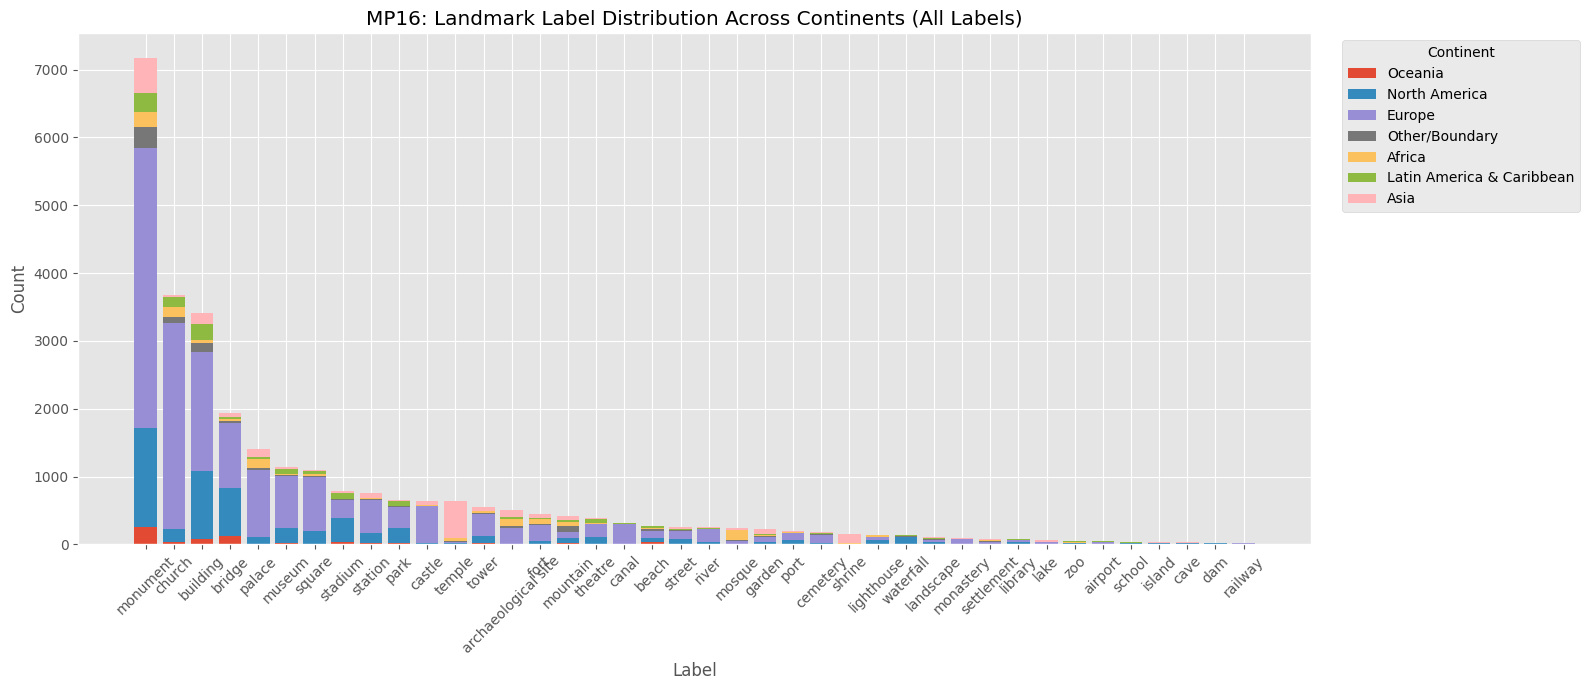

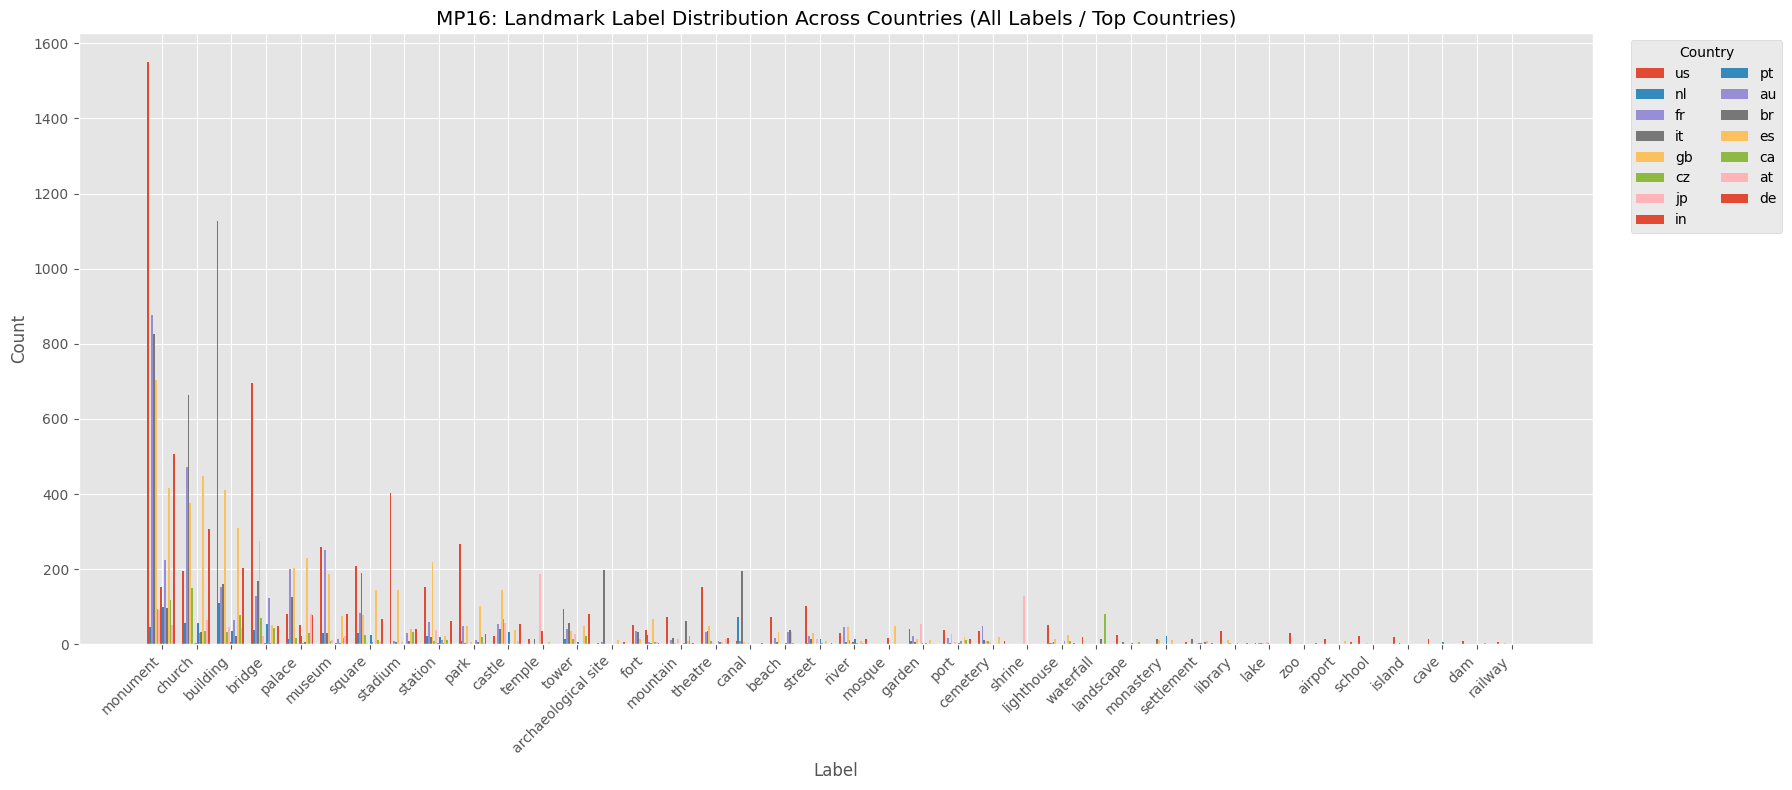

Top labels:
shape: (40, 2)
┌──────────┬──────┐
│ label    ┆ len  │
│ ---      ┆ ---  │
│ str      ┆ u32  │
╞══════════╪══════╡
│ monument ┆ 7176 │
│ church   ┆ 3671 │
│ building ┆ 3414 │
│ bridge   ┆ 1938 │
│ palace   ┆ 1410 │
│ …        ┆ …    │
│ school   ┆ 33   │
│ cave     ┆ 31   │
│ island   ┆ 31   │
│ dam      ┆ 25   │
│ railway  ┆ 22   │
└──────────┴──────┘

Top countries:
shape: (15, 2)
┌──────────────┬──────┐
│ country_code ┆ len  │
│ ---          ┆ ---  │
│ str          ┆ u32  │
╞══════════════╪══════╡
│ us           ┆ 5935 │
│ gb           ┆ 3119 │
│ it           ┆ 2878 │
│ fr           ┆ 2664 │
│ es           ┆ 2249 │
│ …            ┆ …    │
│ nl           ┆ 471  │
│ pt           ┆ 461  │
│ in           ┆ 344  │
│ at           ┆ 333  │
│ br           ┆ 329  │
└──────────────┴──────┘

Continent totals:
shape: (7, 2)
┌───────────────────────────┬───────┐
│ continent                 ┆ len   │
│ ---                       ┆ ---   │
│ str                       ┆ u32   │
╞════════

In [ ]:
import matplotlib.pyplot as plt
import polars as pl

# Use the filtered MP16 files from previous cells.
mp16_train_f = pl.read_csv(
    "../datasets/mp16-reason-train-annot-2-filtered.csv"
).with_columns(pl.lit("train").alias("split"))
mp16_test_f = pl.read_csv(
    "../datasets/mp16-reason-test-annot-2-filtered.csv"
).with_columns(pl.lit("test").alias("split"))
mp16_all = pl.concat([mp16_train_f, mp16_test_f], how="diagonal_relaxed")

# Keep rows with valid label/country/continent.
df = mp16_all.filter(
    pl.col("label").is_not_null() & (pl.col("label") != "unknown")
).with_columns(
    pl.col("continent").fill_null("Unknown").alias("continent"),
    pl.col("country_code").fill_null("UNK"),
)

# Focus on the most frequent labels for readable charts.
TOP_COUNTRIES = 15

label_order = (
    df.group_by("label")
    .len()
    .sort("len", descending=True)
    .select("label")
    .to_series()
    .to_list()
)

df_top = df.filter(pl.col("label").is_in(label_order))

# ------------------------------
# 1) Distribution per label across continents (stacked bar)
# ------------------------------
cont = (
    df_top.group_by(["label", "continent"])
    .len()
    .pivot(values="len", index="label", on="continent")
    .fill_null(0)
)

# Keep label order by global frequency.
cont = cont.with_columns(pl.col("label").cast(pl.Enum(label_order))).sort("label")
cont_labels = cont["label"].cast(pl.String).to_list()
cont_cols = [c for c in cont.columns if c != "label"]

fig, ax = plt.subplots(figsize=(16, 7))
bottom = [0] * len(cont_labels)
for col in cont_cols:
    vals = cont[col].to_list()
    ax.bar(cont_labels, vals, bottom=bottom, label=col)
    bottom = [b + v for b, v in zip(bottom, vals)]

ax.set_title("MP16: Landmark Label Distribution Across Continents (All Labels)")
ax.set_xlabel("Label")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=45)
ax.legend(title="Continent", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# ------------------------------
# 2) Distribution per label across countries (grouped by top countries)
# ------------------------------
country_order = (
    df.group_by("country_code")
    .len()
    .sort("len", descending=True)
    .head(TOP_COUNTRIES)
    .select("country_code")
    .to_series()
    .to_list()
)

df_country = df_top.filter(pl.col("country_code").is_in(country_order))

country_label = (
    df_country.group_by(["label", "country_code"])
    .len()
    .pivot(values="len", index="label", on="country_code")
    .fill_null(0)
)

country_label = country_label.with_columns(
    pl.col("label").cast(pl.Enum(label_order))
).sort("label")
plot_labels = country_label["label"].cast(pl.String).to_list()
country_cols = [c for c in country_label.columns if c != "label"]

# Grouped bars can get wide; use small bar width and legend outside.
fig, ax = plt.subplots(figsize=(18, 8))
num_groups = len(country_cols)
x = list(range(len(plot_labels)))
bar_width = 0.8 / max(num_groups, 1)

for i, cc in enumerate(country_cols):
    vals = country_label[cc].to_list()
    x_pos = [xi - 0.4 + i * bar_width for xi in x]
    ax.bar(x_pos, vals, width=bar_width, label=cc)

ax.set_title(
    "MP16: Landmark Label Distribution Across Countries (All Labels / Top Countries)"
)
ax.set_xlabel("Label")
ax.set_ylabel("Count")
ax.set_xticks(x)
ax.set_xticklabels(plot_labels, rotation=45, ha="right")
ax.legend(title="Country", bbox_to_anchor=(1.02, 1), loc="upper left", ncol=2)
plt.tight_layout()
plt.show()

# ------------------------------
# 3) Balance summaries (optional printouts)
# ------------------------------
print("Top labels:")
print(df.group_by("label").len().sort("len", descending=True))

print("\nTop countries:")
print(
    df.group_by("country_code").len().sort("len", descending=True).head(TOP_COUNTRIES)
)

print("\nContinent totals:")
print(df.group_by("continent").len().sort("len", descending=True))


In [8]:
import polars as pl

df = pl.read_csv("../../datasets/google-landmark/train_w_latlon.csv")
df.head()

landmark_id,input_url,resolved_url,geohack_url,latitude,longitude,error
str,str,str,str,f64,f64,str
null,"""http://commons.wikimedia.org/w…","""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…",-27.2281,152.965,null
null,"""http://commons.wikimedia.org/w…","""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…",51.542186,9.921973,null
null,"""http://commons.wikimedia.org/w…","""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…",56.15,40.4167,null
null,"""http://commons.wikimedia.org/w…","""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…",44.0605,-121.283,null
null,"""http://commons.wikimedia.org/w…","""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…",42.345,1.810556,null
